# Notebook principal
Este notebook contém o fluxo de pré-processamento, treino e explicações SHAP. Execute as células abaixo em ordem.

# Imports

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report,  confusion_matrix
import shap
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

# Lendo o dataset

In [36]:
df = pd.read_csv('../Datasets/LMD-2023-dataset.csv')
df = df[df['Label'] != 2]  

C:\Users\vinic\AppData\Local\Temp\ipykernel_15964\4228867806.py:1: DtypeWarning: Columns (40,53,56,57,58,59,60,61,62,65,66,68,69,70,71,72,73,74,75,76,77,78,79,81,82,83,84,85,87,88,89,90,91,92,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../Datasets/LMD-2023-dataset.csv')


# Começando o treinamento

In [37]:
import sys
sys.path.append('..')
from parser.feature_engineering import extract_behavioral_features

print('Extracting behavioral features...')
df_behavioral = extract_behavioral_features(df)

drop_cols = [
    'Label',
    'ProcessId',
    'ProcessGuid',
    'ProcessKey',
    '_log_file',
    'Image'
]

y = df_behavioral['Label']
X = df_behavioral.drop(columns=drop_cols, errors='ignore')
print('Behavioral features:', X.columns.tolist())


2026-05-26 23:41:23,080 - INFO - Starting feature engineering


Extracting behavioral features...


c:\Projetos\RansonwareData\Train\..\parser\feature_engineering.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(
2026-05-26 23:42:07,450 - INFO - Extracted features for 13014 unique processes


Behavioral features: ['total_events', 'events_per_second', 'max_events_same_second', 'num_created_processes', 'num_created_files', 'file_creation_rate', 'num_registry_modifications', 'num_network_connections', 'num_dns_queries', 'num_unique_ips', 'num_unique_ports', 'suspicious_extensions', 'unique_extensions_modified', 'critical_directory_activity', 'child_process_count', 'suspicious_command_count']


In [38]:
import joblib
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='constant', fill_value=0)

X_encoded = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

joblib.dump(imputer, 'preprocessor.joblib')

print('Preprocessor salvo')


Preprocessor salvo


In [39]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, stratify=y)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [40]:
import joblib

joblib.dump(rf, "modelo_ransomware.joblib")

['modelo_ransomware.joblib']

# Testes da IA

In [41]:
for t in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6]:
    
    y_pred = (prob >= t).astype(int)

    print(f"\nThreshold: {t}")

    print(classification_report(y_test, y_pred))


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.96      0.56      0.70      2509
           1       0.03      0.40      0.06        94

    accuracy                           0.55      2603
   macro avg       0.50      0.48      0.38      2603
weighted avg       0.93      0.55      0.68      2603


Threshold: 0.25
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2509
           1       0.05      0.05      0.05        94

    accuracy                           0.93      2603
   macro avg       0.51      0.51      0.51      2603
weighted avg       0.93      0.93      0.93      2603


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2509
           1       0.05      0.05      0.05        94

    accuracy                           0.93      2603
   macro avg       0.51      0.51      0.51      2603
weighted avg       0.93  

In [42]:
prob = rf.predict_proba(X_test)[:, 1]

threshold = 0.55

y_pred = (prob >= threshold).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2509
           1       0.97      0.76      0.85        94

    accuracy                           0.99      2603
   macro avg       0.98      0.88      0.92      2603
weighted avg       0.99      0.99      0.99      2603

[[2507    2]
 [  23   71]]


In [43]:
X_test[:5000]

,total_events,events_per_second,max_events_same_second,num_created_processes,num_created_files,file_creation_rate,num_registry_modifications,num_network_connections,num_dns_queries,num_unique_ips,num_unique_ports,suspicious_extensions,unique_extensions_modified,critical_directory_activity,child_process_count,suspicious_command_count
11184,1.0,1.00000,1.0,0.0,0.0,0.000000,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
11579,1.0,1.00000,1.0,0.0,0.0,0.000000,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
3017,1.0,1.00000,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
2017,1.0,1.00000,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
4626,1.0,1.00000,1.0,1.0,0.0,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11424,4.0,0.00000,0.0,3.0,0.0,0.000000,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0
12047,25.0,0.00253,7.0,4.0,21.0,0.002125,0.0,0.0,0.0,1.0,1.0,24.0,2.0,0.0,2.0,0.0
8708,1.0,1.00000,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
9731,1.0,1.00000,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0


In [44]:

# NÃO MEXER NESSA CÉLULA
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test[:5000])


In [45]:
shap_values.shape

(2603, 16, 2)

instance_idx= 0 class_index= 0
sv shape= (16,) n_features= 16
base_value= 0.8622123203809224


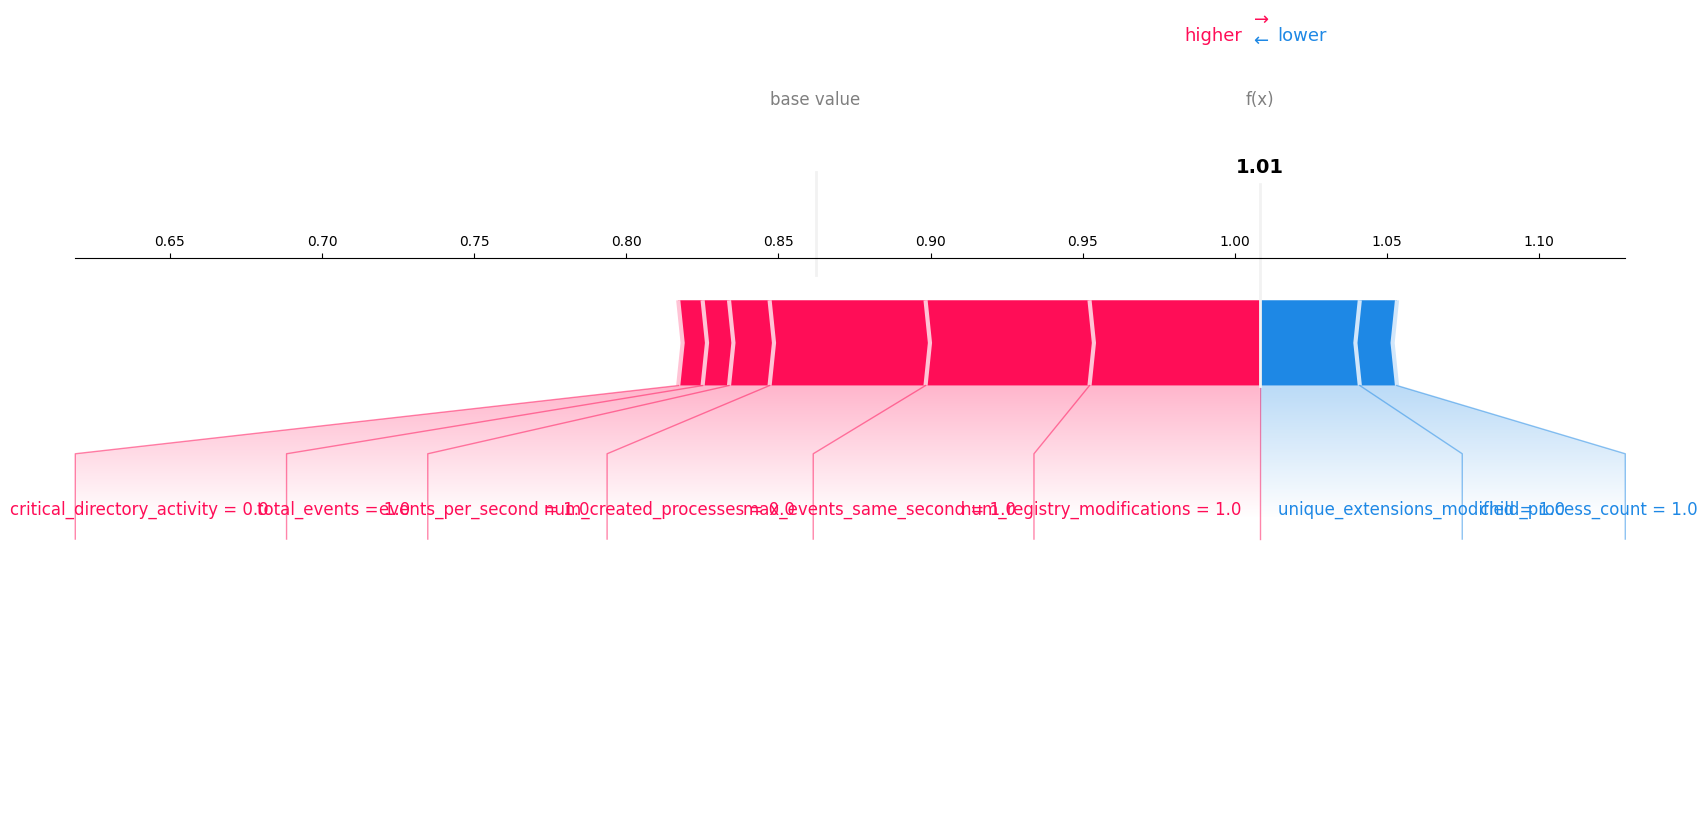

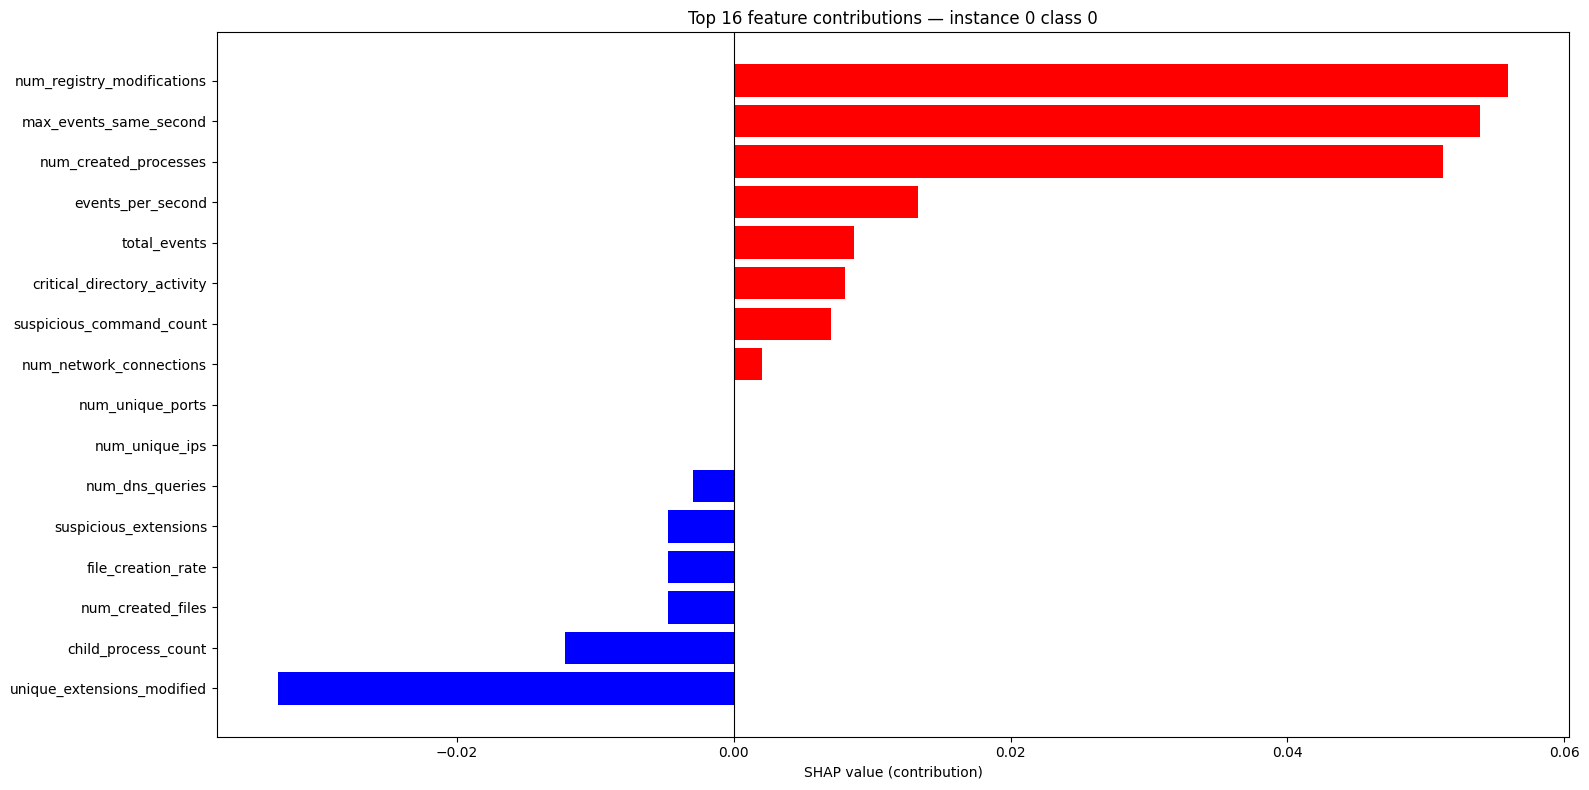

,feature,shap_value
0,num_registry_modifications,0.055936
1,max_events_same_second,0.053895
2,num_created_processes,0.051260
3,unique_extensions_modified,-0.032906
4,events_per_second,0.013336
5,child_process_count,-0.012227
6,total_events,0.008681
7,critical_directory_activity,0.008010
8,suspicious_command_count,0.006993
9,num_created_files,-0.004782


In [46]:
# === Nova célula final: treinar explainer com primeiras 20000 linhas e plotar force (limitado) ===
import numpy as np
import matplotlib.pyplot as plt

# 1) treinar explainer com as primeiras 20000 linhas do treino
train_sample = 20000
explainer2 = shap.TreeExplainer(rf, data=X_train.iloc[:train_sample])

# 2) calcular shap_values para um subset do X_test (rápido)
sv_all = explainer2.shap_values(X_test.iloc[:100])

# 3) escolher instância e classe (por padrão usa a classe predita pelo modelo)
instance_idx = 0
try:
    probs = rf.predict_proba(X_test.iloc[[instance_idx]])[0]
    class_index = int(np.argmax(probs))
except Exception:
    class_index = 0

# 4) extrair vetor 1D de contribuições (sv) suportando vários formatos
if isinstance(sv_all, list):
    arr = sv_all[class_index] if len(sv_all) > class_index else sv_all[0]
    if hasattr(arr, 'ndim') and arr.ndim == 2:
        sv = arr[instance_idx]
    elif hasattr(arr, 'ndim') and arr.ndim == 3:
        sv = arr[instance_idx].reshape(arr.shape[1], -1).sum(axis=1)
    else:
        sv = np.array(arr[instance_idx]).ravel()
elif isinstance(sv_all, np.ndarray):
    if sv_all.ndim == 3:
        # formato: (n_samples, n_features, n_classes)
        sv = sv_all[instance_idx, :, class_index]
    elif sv_all.ndim == 2:
        sv = sv_all[instance_idx]
    else:
        sv = np.array(sv_all[instance_idx]).ravel()
else:
    sv = np.array(sv_all).ravel()

# 5) preparar features alinhadas
n = sv.shape[0]
feat = X_test.iloc[instance_idx, :n].copy()
if feat.shape[0] != n:
    feat = pd.Series(feat.values[:n], index=[f'feat_{i}' for i in range(n)])

# 6) obter base_value do explainer treinado
ev = explainer2.expected_value
if isinstance(ev, (list, np.ndarray)) and np.size(ev) > 1:
    try:
        base_value = float(np.array(ev).ravel()[class_index])
    except Exception:
        base_value = float(np.array(ev).ravel()[0])
else:
    base_value = float(ev)

print('instance_idx=', instance_idx, 'class_index=', class_index)
print('sv shape=', sv.shape, 'n_features=', n)
print('base_value=', base_value)

# --- Limitar force_plot a um número razoável de features (entre 5 e 10) ---
force_top_k = 8
contribs_full = pd.Series(sv, index=feat.index)
top_force = contribs_full.abs().sort_values(ascending=False).head(force_top_k).index.tolist()

# manter a ordem por magnitude (opcional: mostrar do maior ao menor)
top_force_ordered = contribs_full.loc[top_force].reindex(top_force).index.tolist()
sv_reduced = contribs_full.loc[top_force_ordered].values
feat_reduced = feat.loc[top_force_ordered]

# 7) force_plot apenas com as top features selecionadas (AUMENTEI FIGSIZE HORIZONTAL)
try:
    fig = shap.force_plot(
        base_value,
        sv_reduced,
        feat_reduced,
        feature_names=feat_reduced.index.tolist(),
        matplotlib=True,
        contribution_threshold=0.0,
        figsize=(20, max(1.2, force_top_k * 0.9))  # largura aumentada para menos aperto
    )
    plt.show()
except Exception as e:
    print('force_plot error:', e)

# 8) barplot com as top contribuições (por leitura rápida) - aumentei largura também
bar_top_k = 20
top_feats = contribs_full.abs().sort_values(ascending=False).head(bar_top_k).index
vals = contribs_full.loc[top_feats].reindex(top_feats)
vals_sorted = vals.sort_values()
colors = ['red' if v > 0 else 'blue' for v in vals_sorted.values]
plt.figure(figsize=(16, max(4, len(vals_sorted) * 0.5)))  # largura aumentada
plt.barh(vals_sorted.index, vals_sorted.values, color=colors)
plt.axvline(0, color='k', linewidth=0.8)
plt.xlabel('SHAP value (contribution)')
plt.title(f'Top {len(vals_sorted)} feature contributions — instance {instance_idx} class {class_index}')
plt.tight_layout()
plt.show()

# 9) tabela resumida das features mostradas no barplot
display(pd.DataFrame({'feature': vals.index, 'shap_value': vals.values}).reset_index(drop=True))

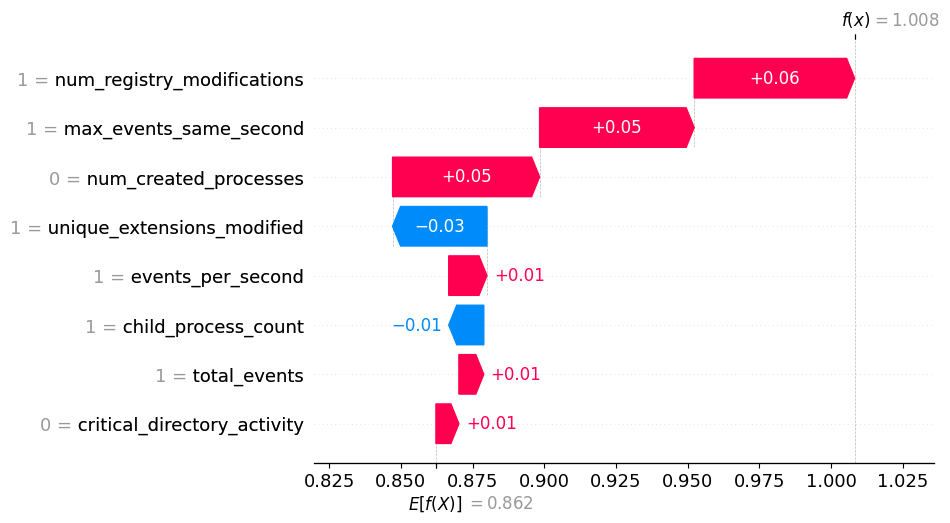

In [47]:
# Waterfall SHAP plot para as top features já selecionadas
import matplotlib.pyplot as plt
try:
    # tenta API moderna (shap.Explanation + shap.plots.waterfall)
    exp = shap.Explanation(
        values=sv_reduced,
        base_values=base_value,
        data=feat_reduced.values,
        feature_names=feat_reduced.index.tolist()
    )
    shap.plots.waterfall(exp, max_display=force_top_k)
    plt.show()
except Exception as e_modern:
    print('modern waterfall failed, trying legacy API -', e_modern)
    try:
        # fallback para versão mais antiga do shap
        shap.plots._waterfall.waterfall_legacy(
            base_value,
            sv_reduced,
            feat_reduced.values,
            feature_names=feat_reduced.index.tolist()
        )
        plt.show()
    except Exception as e_legacy:
        print('waterfall plot failed:', e_legacy)

# fim - se quiser ajustar quantas features aparecem, altere force_top_k na célula anterior

Using class_index = 0 shap_for_plot.shape = (100, 16)


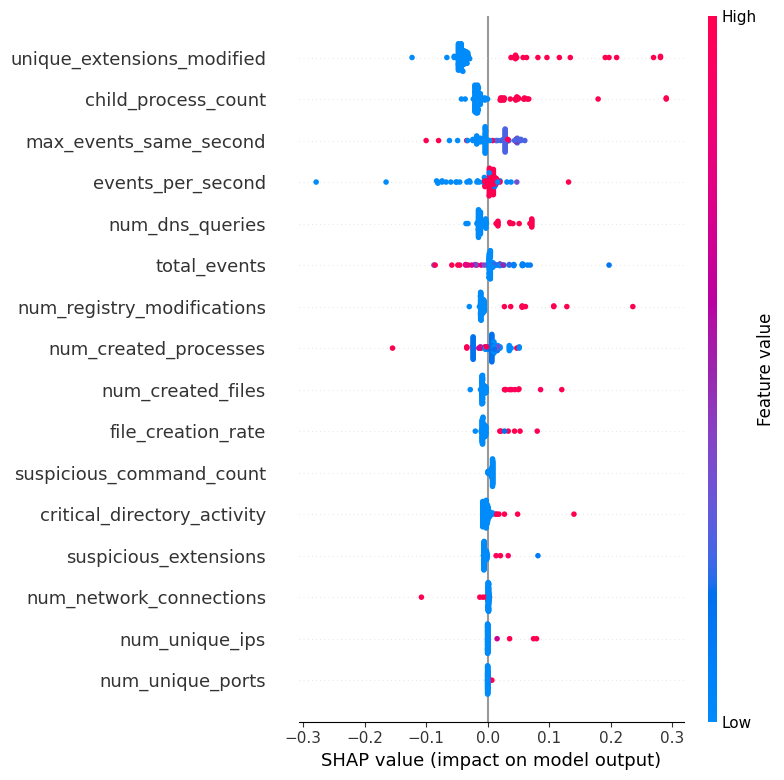

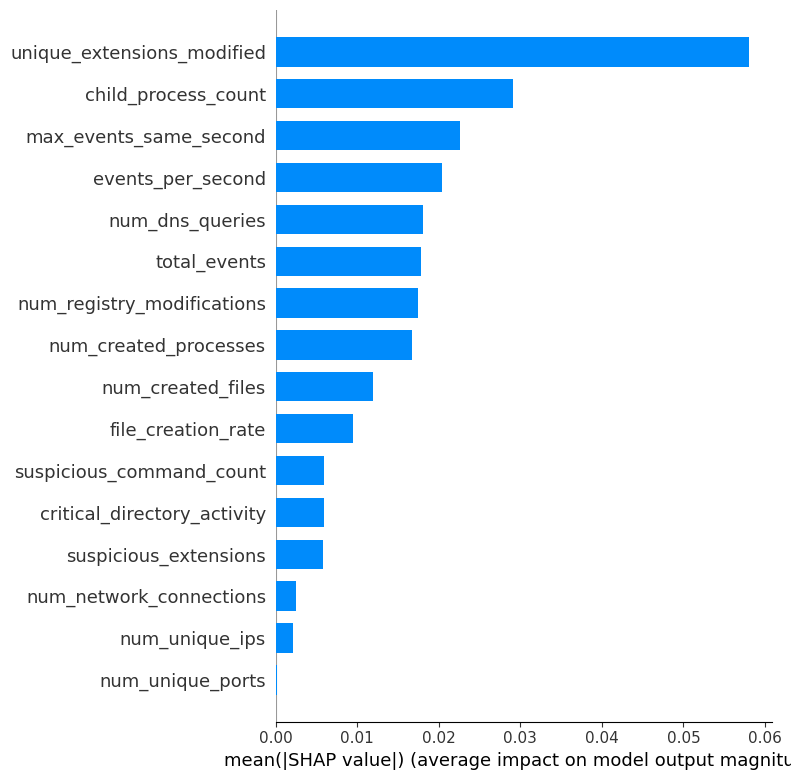

In [48]:
# === Nova célula: SHAP summary plots (dot e bar) ===
import matplotlib.pyplot as plt

# usar mesmo subset usado para sv_all (primeiras 100 linhas calculadas anteriormente)
X_subset = X_test.iloc[:100]

# escolher classe para multiclass: média das probabilidades ou 0 por padrão
try:
    probs_subset = rf.predict_proba(X_subset)
    class_index = int(np.argmax(np.mean(probs_subset, axis=0)))
except Exception:
    class_index = 0

# preparar array de shap values para plot (n_samples, n_features)
if 'sv_all' not in globals():
    raise RuntimeError('sv_all não encontrado — execute a célula que calcula sv_all primeiro')

if isinstance(sv_all, list):
    shap_for_plot = sv_all[class_index]
elif isinstance(sv_all, np.ndarray):
    if sv_all.ndim == 3:
        # formato (n_samples, n_features, n_classes)
        shap_for_plot = sv_all[:, :, class_index]
    else:
        shap_for_plot = sv_all
else:
    shap_for_plot = np.array(sv_all)

print('Using class_index =', class_index, 'shap_for_plot.shape =', getattr(shap_for_plot, 'shape', None))

# alinhar colunas - garantir n_features compatível
if hasattr(X_subset, 'shape') and shap_for_plot.shape[1] != X_subset.shape[1]:
    X_plot = X_subset.iloc[:, :shap_for_plot.shape[1]]
else:
    X_plot = X_subset

# summary dot plot (mais informativo) - ampliar tamanho para legibilidade
plt.figure(figsize=(14,10))
shap.summary_plot(shap_for_plot, X_plot, show=True)

# summary bar plot (média absoluta das contribuições) - complemento
plt.figure(figsize=(12,6))
shap.summary_plot(shap_for_plot, X_plot, plot_type='bar', show=True)

Instância: 0 — classe predita: 0 (prob=1.0000)

Explicação LIME (feature, contribuição):
suspicious_command_count <= 0.00: -0.336786
total_events <= 1.00: -0.125290
num_dns_queries <= 0.00: 0.087435
0.00 < max_events_same_second <= 1.00: -0.085288
num_registry_modifications > 0.00: -0.075618
unique_extensions_modified <= 1.00: 0.075564
file_creation_rate <= 0.00: 0.068203
num_created_files <= 0.00: 0.064035
suspicious_extensions <= 0.00: 0.056075
child_process_count <= 1.00: 0.051512


c:\Users\vinic\.virtualenvs\RansonwareData-Oy5xU5Qp\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


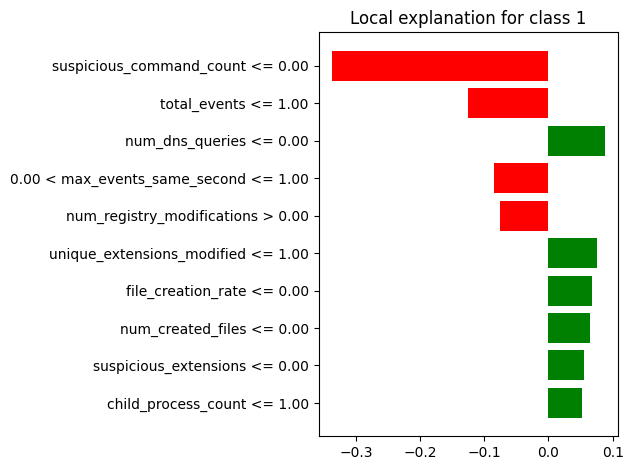

,feature,contribution
0,suspicious_command_count <= 0.00,-0.336786
1,total_events <= 1.00,-0.125290
2,num_dns_queries <= 0.00,0.087435
3,0.00 < max_events_same_second <= 1.00,-0.085288
4,num_registry_modifications > 0.00,-0.075618
5,unique_extensions_modified <= 1.00,0.075564
6,file_creation_rate <= 0.00,0.068203
7,num_created_files <= 0.00,0.064035
8,suspicious_extensions <= 0.00,0.056075
9,child_process_count <= 1.00,0.051512


In [49]:
# === Nova célula: Interpretação local com LIME ===
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

# ajuste aqui a instância que quer explicar
instance_idx = 0
num_features = 10  # quantas features mostrar na explicação

# preparar dados para o explainer
X_train_arr = X_train.values if hasattr(X_train, 'values') else X_train
feature_names = X_train.columns.tolist()
class_names = [str(c) for c in (getattr(rf, 'classes_', np.unique(y_train)))]

explainer_lime = LimeTabularExplainer(
    X_train_arr,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

# função de predição para LIME (usa predict_proba do modelo)
predict_fn = lambda x: rf.predict_proba(x)

# gerar explicação para a instância escolhida
exp = explainer_lime.explain_instance(X_test.iloc[instance_idx].values, predict_fn, num_features=num_features)

# imprimir resumo textual
pred_probs = rf.predict_proba(X_test.iloc[[instance_idx]])[0]
pred_class = int(np.argmax(pred_probs))
print(f'Instância: {instance_idx} — classe predita: {class_names[pred_class]} (prob={pred_probs[pred_class]:.4f})')
print('\nExplicação LIME (feature, contribuição):')
for feat, weight in exp.as_list():
    print(f'{feat}: {weight:.6f}')

# mostrar figura matplotlib gerada pelo LIME
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

# também montar DataFrame com as contribuições para exportar/incluir no relatório
df_lime = pd.DataFrame(exp.as_list(), columns=['feature', 'contribution'])
display(df_lime)